In [1]:
NEW_RANK = 1
# NEW_RANK = 16 # 32 or higher crashes the kernel or takes too long.

In [2]:
import torch
from tqdm.auto import tqdm

from src.utils.lora_vector_utils import LoRAVector, LoRAVectorCollection

REPO = "maius/llama-3.1-8b-it-personas"

adapters = [
    "sarcasm",
    "humor",
    "remorse",
    "nonchalance",
    "impulsiveness",
    "sycophancy",
    "mathematical",
    "poeticism",
    "goodness",
    "loving",
]

In [3]:
# Load persona adapters from HuggingFace
persona_vectors = {}
for name in tqdm(adapters):
    vec = LoRAVector.from_hub(REPO, subfolder=name)
    if NEW_RANK is not None:
        vec = vec.rank_reduce(NEW_RANK)
    persona_vectors[name] = vec

# Base = zero vector (unmodified model)
ref_vec = next(iter(persona_vectors.values()))
persona_vectors["base"] = ref_vec.zero_like()

# Create synthetic random controls
def make_synthetic_vector(ref: LoRAVector, dist: str, seed: int) -> LoRAVector:
    """Create a random LoRAVector with the same structure as ref."""
    torch.manual_seed(seed)
    factors = {}
    for name, (B, A) in ref.factors.items():
        if dist == "gaussian":
            factors[name] = (torch.randn_like(B), torch.randn_like(A))
        elif dist == "uniform":
            factors[name] = (torch.zeros_like(B).uniform_(-1, 1), torch.zeros_like(A).uniform_(-1, 1))
        elif dist == "zipf":
            def zipf_vals(shape, s=1.5):
                d = shape[0] * shape[1]
                ranks = torch.arange(1, d + 1).float()
                weights = ranks ** (-s)
                weights /= weights.sum()
                signs = torch.randint(0, 2, (d,)).float() * 2 - 1
                return (weights * signs).reshape(shape)
            factors[name] = (zipf_vals(B.shape), zipf_vals(A.shape))
    return LoRAVector(factors)

synthetic_vectors = {}
for dist in ["gaussian", "uniform", "zipf"]:
    seed = torch.randint(0, 2**32, (1,)).item()
    synthetic_vectors[f"{dist}_0"] = make_synthetic_vector(ref_vec, dist, seed)

# Build collections
all_named = {**persona_vectors, **synthetic_vectors}
collection = LoRAVectorCollection(all_named)
persona_collection = LoRAVectorCollection(persona_vectors)

  0%|          | 0/10 [00:00<?, ?it/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

...

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

In [15]:
pca_result = persona_collection.pca(normalize=False)

coords = pca_result.input_coords
eigenvalues = pca_result.eigenvalues
explained = pca_result.explained_variance

sum_ = 0
for i, e in enumerate(explained):
    sum_ += e
    print(f"  PC{i}: {e:.2%} Cumulative {sum_:.2%}")

  PC0: 15.80% Cumulative 15.80%
  PC1: 14.23% Cumulative 30.03%
  PC2: 12.46% Cumulative 42.49%
  PC3: 11.32% Cumulative 53.81%
  PC4: 10.50% Cumulative 64.30%
  PC5: 9.20% Cumulative 73.51%
  PC6: 8.32% Cumulative 81.82%
  PC7: 8.22% Cumulative 90.04%
  PC8: 5.95% Cumulative 95.99%
  PC9: 4.01% Cumulative 100.00%


In [19]:
import plotly.graph_objects as go

persona_names = persona_collection.names

n_pcs = coords.shape[1]
combos = [(i, i+1, i+2) for i in range(n_pcs - 2)]

n_personas = len(persona_names)
fig = go.Figure()

for combo in combos:
    x_pc, y_pc, z_pc = combo
    for i, persona in enumerate(persona_names):
        is_base = persona == "base"
        fig.add_trace(go.Scatter3d(
            x=[coords[i, x_pc].item()],
            y=[coords[i, y_pc].item()],
            z=[coords[i, z_pc].item()],
            mode='markers+text',
            marker=dict(
                size=10 if is_base else 6,
                color='black' if is_base else None,
                symbol='diamond' if is_base else 'circle',
            ),
            text=[persona],
            textposition='top center',
            textfont=dict(size=12 if is_base else 10),
            name=persona,
            visible=(combo == (0, 1, 2)),
            showlegend=(combo == (0, 1, 2)),
        ))

buttons = []
for k, (x_pc, y_pc, z_pc) in enumerate(combos):
    visibility = [False] * (len(combos) * n_personas)
    for j in range(n_personas):
        visibility[k * n_personas + j] = True
    buttons.append(dict(
        method='update',
        label=f"PC{x_pc+1}, PC{y_pc+1}, PC{z_pc+1}",
        args=[
            {'visible': visibility},
            {'scene.xaxis.title': f"PC{x_pc+1} ({explained[x_pc]:.1%})",
             'scene.yaxis.title': f"PC{y_pc+1} ({explained[y_pc]:.1%})",
             'scene.zaxis.title': f"PC{z_pc+1} ({explained[z_pc]:.1%})"},
        ],
    ))

fig.update_layout(
    title=f"LoRA Adapter PCA — top 3 dims explain {explained[:3].sum():.1%} of variance",
    scene=dict(
        xaxis_title=f"PC1 ({explained[0]:.1%})",
        yaxis_title=f"PC2 ({explained[1]:.1%})",
        zaxis_title=f"PC3 ({explained[2]:.1%})",
    ),
    width=900, height=700,
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.0, y=1.1,
        xanchor='left',
        yanchor='top',
    )],
    annotations=[dict(
        text="PCs:", x=0.0, y=1.15,
        xref="paper", yref="paper",
        showarrow=False,
    )],
)

fig.show()

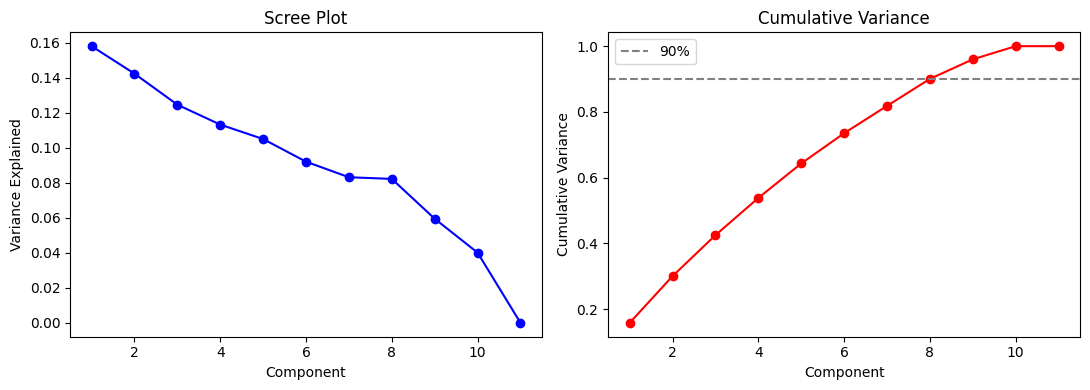

In [20]:
import matplotlib.pyplot as plt

eigenvalues_safe = eigenvalues.clamp(min=0)
total = eigenvalues_safe.sum()
var_explained = (eigenvalues_safe / total).cpu().numpy()
cumulative = var_explained.cumsum()

k = min(20, len(var_explained))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(range(1, k+1), var_explained[:k], 'bo-')
ax1.set(xlabel='Component', ylabel='Variance Explained', title='Scree Plot')

ax2.plot(range(1, k+1), cumulative[:k], 'ro-')
ax2.axhline(0.9, color='gray', linestyle='--', label='90%')
ax2.set(xlabel='Component', ylabel='Cumulative Variance', title='Cumulative Variance')
ax2.legend()

plt.tight_layout()
plt.show()

Largest spectral gap: between PC8 and PC9 (gap=6.3455)
  → suggests retaining 8 components
Effective rank: 9.40
Participation ratio: 8.94
Spectral entropy: 0.973 (0=concentrated, 1=diffuse)


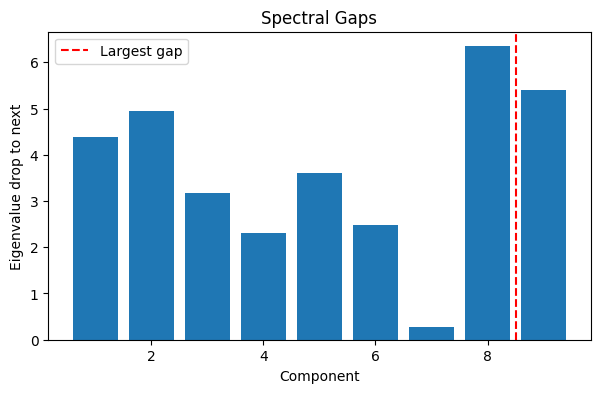

In [21]:
def spectral_measures(eigenvalues):
    eigs = eigenvalues.clamp(min=0)
    eigs = eigs[eigs > 0]  # drop zeros for log stability
    
    total = eigs.sum()
    p = eigs / total

    # Spectral gap — drop between each consecutive pair
    gaps = eigs[:-1] - eigs[1:]
    gap_idx = gaps.argmax().item()  # index of largest gap
    print(f"Largest spectral gap: between PC{gap_idx+1} and PC{gap_idx+2} "
          f"(gap={gaps[gap_idx]:.4f})")
    print(f"  → suggests retaining {gap_idx+1} components")

    # Effective rank (entropy-based)
    eff_rank = torch.exp(-(p * p.log()).sum())
    print(f"Effective rank: {eff_rank:.2f}")

    # Participation ratio
    pr = total**2 / (eigs**2).sum()
    print(f"Participation ratio: {pr:.2f}")

    # Spectral entropy
    entropy = -(p * p.log()).sum()
    max_entropy = torch.log(torch.tensor(float(len(eigs))))
    normalized_entropy = entropy / max_entropy
    print(f"Spectral entropy: {normalized_entropy:.3f} (0=concentrated, 1=diffuse)")

    # Plot gaps
    k = min(20, len(gaps))
    plt.figure(figsize=(7, 4))
    plt.bar(range(1, k+1), gaps[:k].cpu().numpy())
    plt.axvline(gap_idx + 1.5, color='red', linestyle='--', label=f'Largest gap')
    plt.xlabel('Component')
    plt.ylabel('Eigenvalue drop to next')
    plt.title('Spectral Gaps')
    plt.legend()
    plt.show()

spectral_measures(eigenvalues)

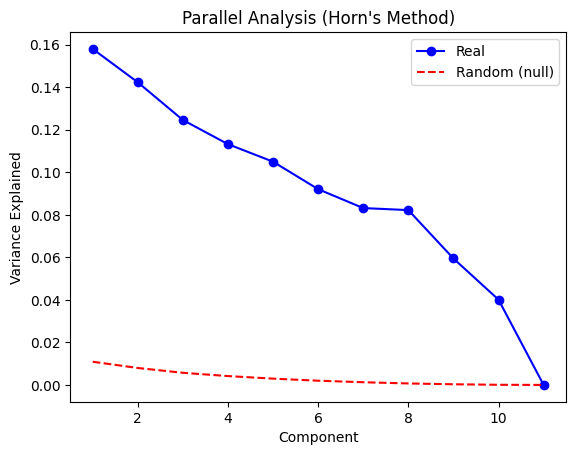

Retain 10 components by Horn's criterion


In [22]:
def parallel_analysis(eigenvalues, n, n_simulations=100):
    """Horn's method"""
    random_eigenvalues = []
    for _ in range(n_simulations):
        # Random Gram matrix of same size
        R = torch.randn(n, n)
        G_rand = R @ R.T / n
        ones_n = torch.ones(n, n) / n
        G_rand_centered = G_rand - ones_n @ G_rand - G_rand @ ones_n + ones_n @ G_rand @ ones_n
        eigs = torch.linalg.eigh(G_rand_centered).eigenvalues.flip(0)
        random_eigenvalues.append(eigs)
    
    random_mean = torch.stack(random_eigenvalues).mean(0)
    total = eigenvalues.clamp(min=0).sum()
    
    real = (eigenvalues / total).cpu().numpy()
    null = (random_mean / total).cpu().numpy()
    
    k = min(20, len(real))
    plt.plot(range(1, k+1), real[:k], 'bo-', label='Real')
    plt.plot(range(1, k+1), null[:k], 'r--', label='Random (null)')
    plt.xlabel('Component')
    plt.ylabel('Variance Explained')
    plt.title("Parallel Analysis (Horn's Method)")
    plt.legend()
    plt.show()
    
    n_retain = (eigenvalues[:k] > random_mean[:k]).sum().item()
    print(f"Retain {n_retain} components by Horn's criterion")

parallel_analysis(eigenvalues, n=len(persona_collection))

In [23]:
import pandas as pd

G_cosine = collection.cosine_similarity_matrix()
df = pd.DataFrame(G_cosine.numpy(), index=collection.names, columns=collection.names)
print(df.round(3))

               sarcasm  humor  remorse  nonchalance  impulsiveness  \
sarcasm          1.000  0.406    0.186        0.286          0.281   
humor            0.406  1.000    0.219        0.359          0.343   
remorse          0.186  0.219    1.000        0.193          0.222   
nonchalance      0.286  0.359    0.193        1.000          0.354   
impulsiveness    0.281  0.343    0.222        0.354          1.000   
sycophancy       0.223  0.262    0.264        0.229          0.273   
mathematical     0.205  0.298    0.191        0.201          0.215   
poeticism        0.181  0.250    0.136        0.189          0.186   
goodness         0.191  0.292    0.210        0.210          0.212   
loving           0.203  0.306    0.227        0.269          0.253   
base             0.000  0.000    0.000        0.000          0.000   
gaussian_0       0.000  0.000    0.000        0.000          0.000   
uniform_0       -0.000 -0.000    0.000        0.000          0.000   
zipf_0          -0.0

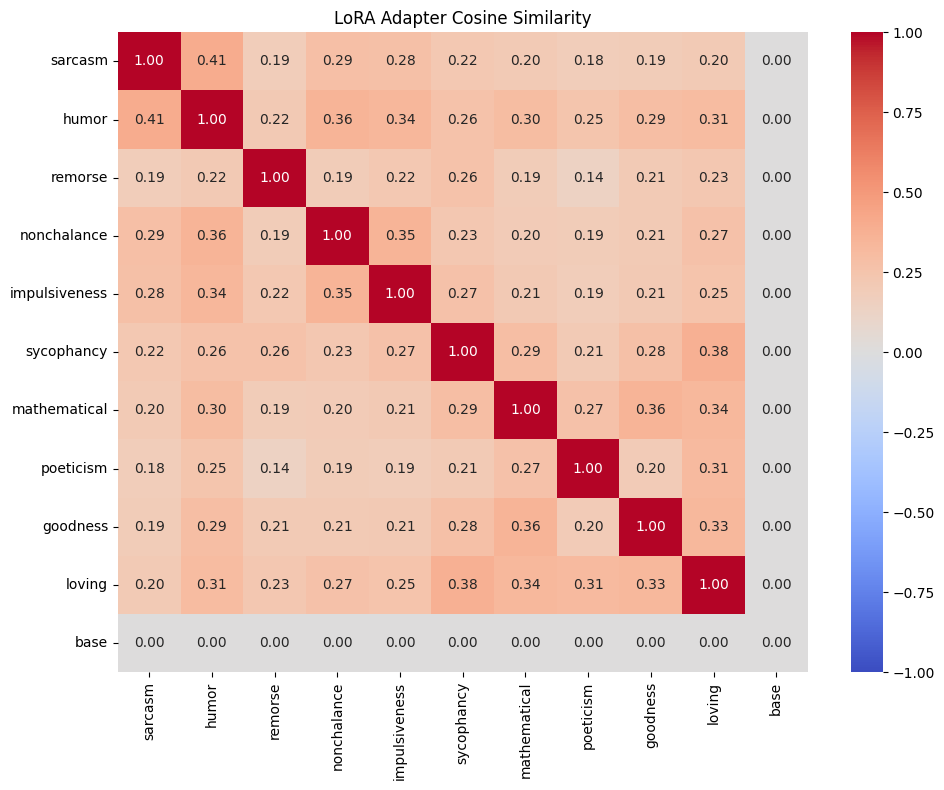

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df[[col for col in df if all(x not in col for x in ("gaussian", "uniform", "zipf"))]].drop(index=[col for col in df.index if any(x in col for x in ("gaussian", "uniform", "zipf"))]),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title("LoRA Adapter Cosine Similarity")
plt.tight_layout()
plt.show()

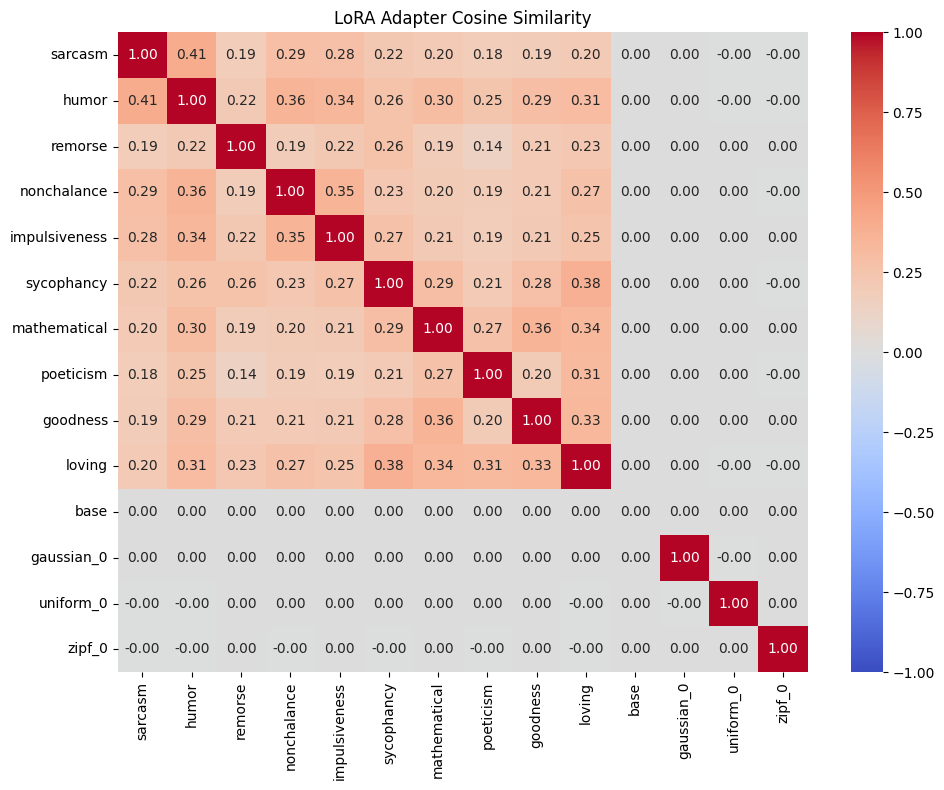

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title("LoRA Adapter Cosine Similarity")
plt.tight_layout()
plt.show()